# 📥 Phase 1: Data Collection

## 📌 Step 2: Create Project Folder & Download Stock Data

### Objective

In this step, we will:

- Create a folder to store the stock datasets.
- Download historical stock market data using the **Yahoo Finance (yfinance)** library.
- Save the downloaded datasets as CSV files for future use.
- Build a reusable dataset that can be used for training the Hybrid CNN + LSTM model.

### Why is this step important?

A Deep Learning model requires historical stock market data for training.

Instead of manually downloading CSV files, we use **yfinance** because it:

- Provides free historical stock market data.
- Downloads the latest available data directly from Yahoo Finance.
- Produces clean and structured datasets.
- Is widely used in finance and machine learning projects.

Import Required Libraries

In [24]:
# ==========================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ==========================================================

# yfinance:
# Used to download real-time historical stock market data
import yfinance as yf

# pandas:
# Used for data loading, cleaning, and manipulation
import pandas as pd

# numpy:
# Used for numerical operations
import numpy as np

# matplotlib:
# Used for creating visualizations and graphs
import matplotlib.pyplot as plt

# seaborn:
# Used for advanced statistical visualizations
import seaborn as sns

# os:
# Used for handling files and folders
import os

# Display graphs directly inside notebook
%matplotlib inline


print("Libraries imported successfully!")

Libraries imported successfully!


Create Project Folder & Download Stock Data

In [25]:
# ==========================================================
# CELL 2 : CREATE DATA FOLDER
# ==========================================================

# This folder will store all downloaded stock datasets.

data_folder = "../data/stocks"

# Create the folder if it doesn't already exist.
os.makedirs(data_folder, exist_ok=True)

print("Data folder is ready.")

Data folder is ready.


Download Multiple Stocks

In [26]:
# ==========================================================
# CELL 3 : DOWNLOAD STOCK DATA
# ==========================================================

# List of stock ticker symbols.
# These are the companies our dashboard will support.

stocks = [
    "AAPL",    # Apple
    "MSFT",    # Microsoft
    "TSLA",    # Tesla
    "AMZN",    # Amazon
    "GOOGL"    # Google
]

# Dictionary to store all downloaded datasets.
stock_data = {}

# Loop through each stock ticker.
for stock in stocks:

    print(f"Downloading {stock} ...")

    # Download historical stock data.
    data = yf.download(
        stock,
        start="2015-01-01",
        end="2025-01-01",
        progress=False
    )

    # Save the dataset in the dictionary.
    stock_data[stock] = data

    # Save the dataset as a CSV file.
    data.to_csv(f"{data_folder}/{stock}.csv")

print("\nAll stock datasets downloaded successfully!")


All stock datasets downloaded successfully!


Check Downloaded Files

In [27]:
# ==========================================================
# CELL 4 : VERIFY DOWNLOADED FILES
# ==========================================================

# Display all CSV files saved in the stocks folder.

print("Downloaded Files:\n")

for file in os.listdir(data_folder):
    print(file)

Downloaded Files:

AAPL.csv
aapl.us.txt
AMZN.csv
amzn.us.txt
GOOGL.csv
MSFT.csv
msft.us.txt
stock_market_data.csv
TSLA.csv
tsla.us.txt


Load Apple Dataset

In [28]:
# ==========================================================
# CELL 5 : LOAD APPLE DATASET
# ==========================================================

# Read the Apple stock dataset.

aapl_df = pd.read_csv(f"{data_folder}/AAPL.csv")

# Display the first five rows.

aapl_df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,24.192604064941406,24.659506182275138,23.75446781268404,24.648441478964468,212818400
3,2015-01-05,23.511062622070312,24.042136374239757,23.325187737341313,23.962475227002493,257142000
4,2015-01-06,23.513273239135742,23.772171094232995,23.152584838795235,23.575231527032173,263188400


Clean yfinance Dataset

In [29]:
# ==========================================================
# CELL 6 : CLEAN YFINANCE DATASET
# ==========================================================


# Display current column structure

print("Before Cleaning:")
print(aapl_df.head())


# ----------------------------------------------------------
# Remove unnecessary first two rows
# ----------------------------------------------------------

# Row 0 contains ticker name
# Row 1 contains column description
# Actual stock data starts from row 2

aapl_df = aapl_df.iloc[2:].reset_index(drop=True)


# ----------------------------------------------------------
# Rename first column as Date
# ----------------------------------------------------------

aapl_df.rename(
    columns={"Price": "Date"},
    inplace=True
)


# ----------------------------------------------------------
# Convert Date column into datetime format
# ----------------------------------------------------------

aapl_df["Date"] = pd.to_datetime(
    aapl_df["Date"]
)


# ----------------------------------------------------------
# Convert remaining columns into numeric format
# ----------------------------------------------------------

for column in aapl_df.columns:

    if column != "Date":
        
        aapl_df[column] = pd.to_numeric(
            aapl_df[column],
            errors="coerce"
        )


# Display cleaned dataset

print("After Cleaning:")

aapl_df.head()

Before Cleaning:
        Price               Close                High                 Low  \
0      Ticker                AAPL                AAPL                AAPL   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-02  24.192604064941406  24.659506182275138   23.75446781268404   
3  2015-01-05  23.511062622070312  24.042136374239757  23.325187737341313   
4  2015-01-06  23.513273239135742  23.772171094232995  23.152584838795235   

                 Open     Volume  
0                AAPL       AAPL  
1                 NaN        NaN  
2  24.648441478964468  212818400  
3  23.962475227002493  257142000  
4  23.575231527032173  263188400  
After Cleaning:


,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
1,2015-01-05,23.511063,24.042136,23.325188,23.962475,257142000
2,2015-01-06,23.513273,23.772171,23.152585,23.575232,263188400
3,2015-01-07,23.842974,23.942549,23.610629,23.721269,160423600
4,2015-01-08,24.759077,24.816610,24.053192,24.170472,237458000


Check Dataset Information

In [30]:
# ==========================================================
# CELL 7 : DATASET INFORMATION
# ==========================================================


print("Dataset Shape:")
print(aapl_df.shape)


print("\nDataset Information:")

aapl_df.info()

Dataset Shape:
(2516, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2516 non-null   datetime64[ns]
 1   Close   2516 non-null   float64       
 2   High    2516 non-null   float64       
 3   Low     2516 non-null   float64       
 4   Open    2516 non-null   float64       
 5   Volume  2516 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 118.1 KB


Check Missing Values

In [31]:
# ==========================================================
# CELL 8 : CHECK MISSING VALUES
# ==========================================================


print(
    aapl_df.isnull().sum()
)

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


PHASE 2: Exploratory Data Analysis (EDA)

Check Dataset Information

In [32]:
# ==========================================================
# CELL 9 : DISPLAY DATASET INFORMATION
# ==========================================================

# info() gives:
# 1. Total rows
# 2. Total columns
# 3. Data types
# 4. Missing values
# 5. Memory usage

print("=" * 60)
print("APPLE STOCK DATASET INFORMATION")
print("=" * 60)

aapl_df.info()

APPLE STOCK DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2516 non-null   datetime64[ns]
 1   Close   2516 non-null   float64       
 2   High    2516 non-null   float64       
 3   Low     2516 non-null   float64       
 4   Open    2516 non-null   float64       
 5   Volume  2516 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 118.1 KB


Check Missing Values

In [33]:
# ==========================================================
# CELL 10 : CHECK MISSING VALUES
# ==========================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(aapl_df.isnull().sum())

MISSING VALUES
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


Statistical Summary

In [34]:
# ==========================================================
# CELL 11 : STATISTICAL SUMMARY
# ==========================================================

# describe() calculates:
# Mean
# Standard Deviation
# Minimum
# Maximum
# Quartiles

print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

aapl_df.describe()

STATISTICAL SUMMARY


,Date,Close,High,Low,Open,Volume
count,2516,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,2019-12-31 19:03:31.764706048,93.684877,94.594694,92.673089,93.598213,1.170853e+08
min,2015-01-02 00:00:00,20.565868,20.868639,20.367814,20.488465,2.323470e+07
25%,2017-07-02 06:00:00,35.157628,35.554803,34.780279,35.177797,7.105610e+07
50%,2020-01-01 00:00:00,64.268631,64.822327,63.468149,64.109460,1.003646e+08
75%,2022-06-30 06:00:00,149.955399,151.700199,147.992790,149.778500,1.426216e+08
max,2024-12-31 00:00:00,257.375580,258.448740,255.994420,256.550862,6.488252e+08
std,NaN,65.319931,65.912255,64.634534,65.239868,6.839614e+07


Plot Closing Price

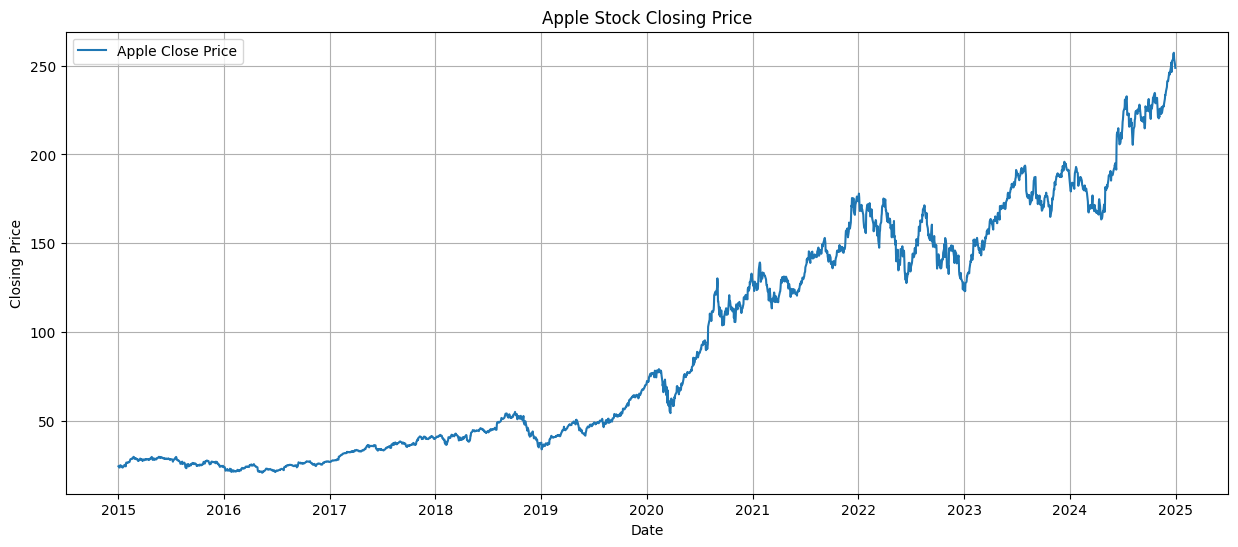

In [35]:
# ==========================================================
# CELL 12 : APPLE CLOSING PRICE
# ==========================================================

# Create figure
plt.figure(figsize=(15,6))

# Plot Closing Price
plt.plot(
    aapl_df["Date"],
    aapl_df["Close"],
    label="Apple Close Price"
)

# Chart Title
plt.title("Apple Stock Closing Price")

# X-axis label
plt.xlabel("Date")

# Y-axis label
plt.ylabel("Closing Price")

# Grid
plt.grid(True)

# Legend
plt.legend()

# Show graph
plt.show()

Plot Trading Volume

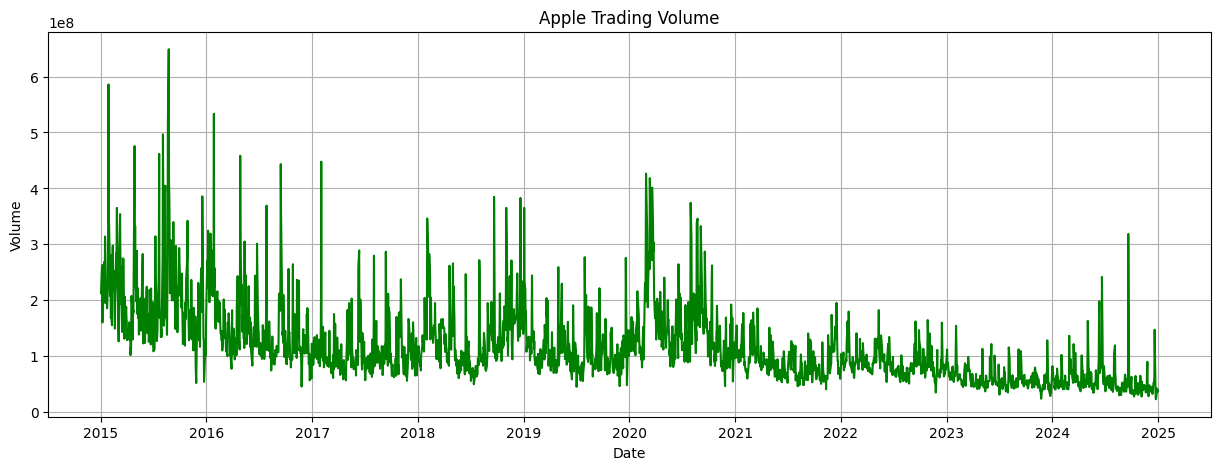

In [36]:
# ==========================================================
# CELL 13 : APPLE TRADING VOLUME
# ==========================================================

plt.figure(figsize=(15,5))

plt.plot(
    aapl_df["Date"],
    aapl_df["Volume"],
    color="green"
)

plt.title("Apple Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid(True)

plt.show()

Plot Open vs Close Price

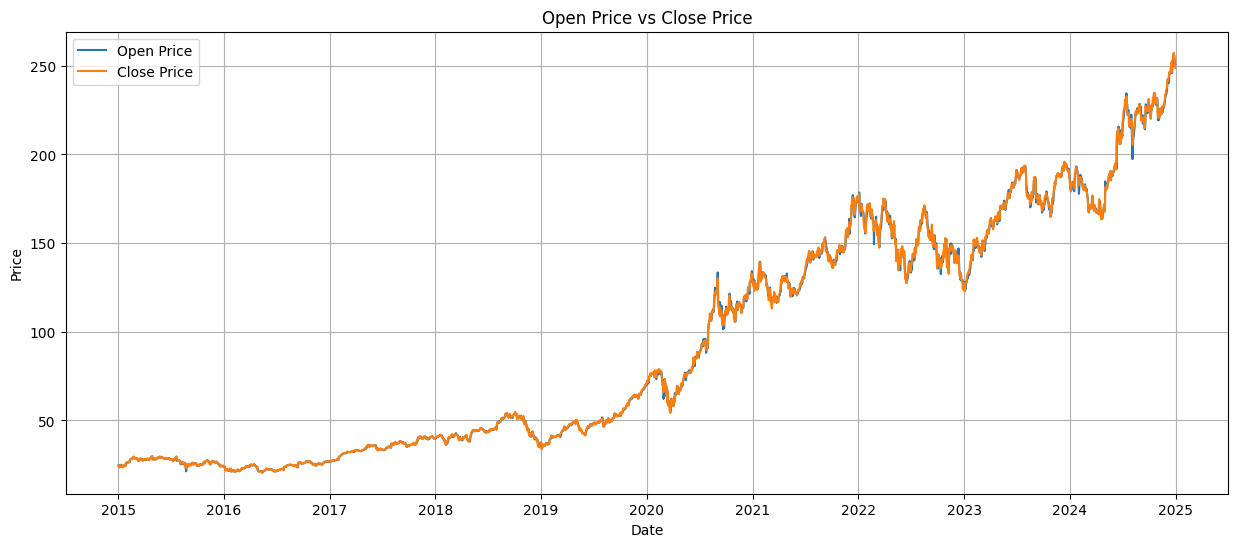

In [37]:
# ==========================================================
# CELL 14 : OPEN PRICE vs CLOSE PRICE
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    aapl_df["Date"],
    aapl_df["Open"],
    label="Open Price"
)

plt.plot(
    aapl_df["Date"],
    aapl_df["Close"],
    label="Close Price"
)

plt.title("Open Price vs Close Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

Select the Close Price

In [38]:
# ==========================================================
# CELL 15 : SELECT CLOSING PRICE
# ==========================================================

# We are selecting only the 'Close' column because
# our first CNN + LSTM model will predict the closing price.

close_data = aapl_df[["Close"]]

# Display the first five rows

print("Closing Price Dataset:")

close_data.head()

Closing Price Dataset:


,Close
0,24.192604
1,23.511063
2,23.513273
3,23.842974
4,24.759077


Plot Closing Price

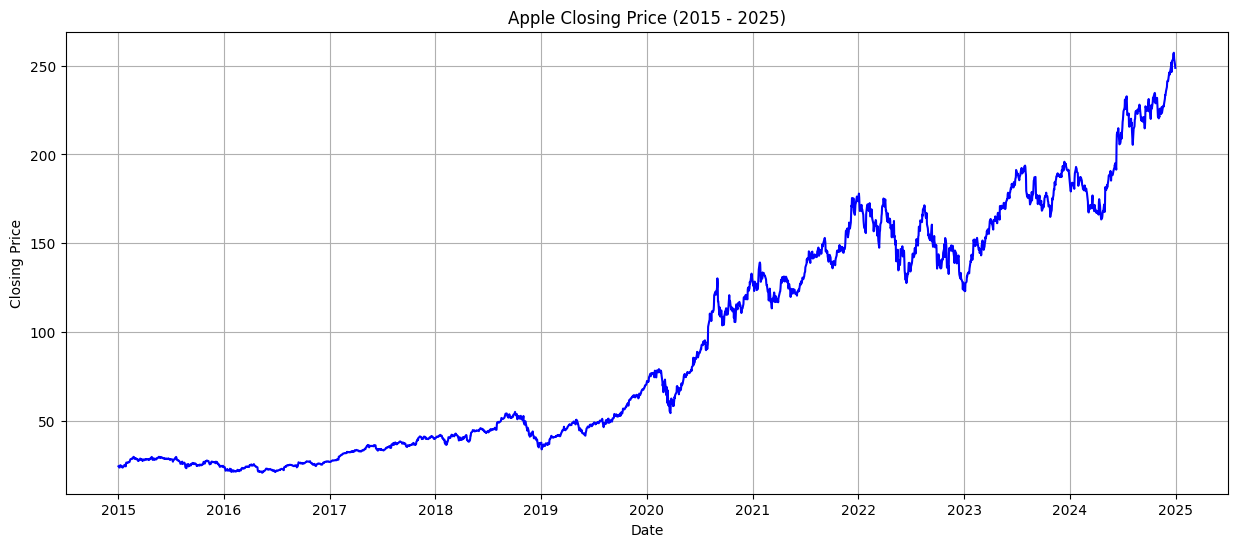

In [39]:
# ==========================================================
# CELL 16 : VISUALIZE CLOSING PRICE
# ==========================================================

# Create figure

plt.figure(figsize=(15,6))

# Plot the Close Price

plt.plot(
    aapl_df["Date"],
    close_data,
    color="blue"
)

# Chart title

plt.title("Apple Closing Price (2015 - 2025)")

# X-axis label

plt.xlabel("Date")

# Y-axis label

plt.ylabel("Closing Price")

# Display grid

plt.grid(True)

# Show graph

plt.show()

Check Shape

In [40]:
# ==========================================================
# CELL 17 : CHECK DATA SHAPE
# ==========================================================

print("Shape of Closing Price Dataset:")

print(close_data.shape)

Shape of Closing Price Dataset:
(2516, 1)


Phase 3: Data Preprocessing

📌 Step 1: Feature Selection
🎯 Objective

Select only the Closing Price because we want to predict the future closing price of the stock.

Deep learning models don't always need every feature. For this project, we'll train the CNN-LSTM model using only the Close column

In [41]:
# ==========================================================
# Step 1: Feature Selection
# ==========================================================

# Select only the 'Close' column from the cleaned dataset.
# Double brackets [[]] keep the result as a DataFrame instead of a Series.

close_data = aapl_df[['Close']]

# Display the first five rows
print("First Five Rows:")
print(close_data.head())

# Display the shape of the dataset
print("\nShape of Dataset:")
print(close_data.shape)

First Five Rows:
       Close
0  24.192604
1  23.511063
2  23.513273
3  23.842974
4  24.759077

Shape of Dataset:
(2516, 1)


Step 2: Import MinMaxScaler
🎯 Objective

Import the MinMaxScaler class from Scikit-Learn.

In [42]:
# ==========================================================
# Step 2: Import MinMaxScaler
# ==========================================================

# Import MinMaxScaler for feature scaling

from sklearn.preprocessing import MinMaxScaler

Why do we use MinMaxScaler?

Deep learning models perform better when all input values lie within the same range.

MinMaxScaler converts data into the range 0 to 1.

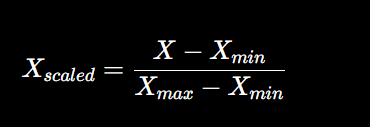



Step 3: Normalize Data
🎯 Objective

Normalize the closing prices between 0 and 1.

In [43]:
# ==========================================================
# Step 3: Normalize the Closing Price
# ==========================================================

# Create an object of MinMaxScaler
# feature_range=(0,1) scales all values between 0 and 1

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler on the Close column and transform the data
scaled_data = scaler.fit_transform(close_data)

# Display first 10 scaled values
print("First 10 Scaled Values:\n")
print(scaled_data[:10])

# Display shape
print("\nShape of Scaled Dataset:")
print(scaled_data.shape)

First 10 Scaled Values:

[[0.01531498]
 [0.01243697]
 [0.0124463 ]
 [0.01383856]
 [0.01770708]
 [0.01781922]
 [0.01524021]
 [0.01614661]
 [0.01575416]
 [0.01296958]]

Shape of Scaled Dataset:
(2516, 1)


In [44]:
# ==========================================================
# Compare Original and Scaled Values
# ==========================================================

comparison = pd.DataFrame({
    "Original Price": close_data['Close'].head(10).values,
    "Scaled Price": scaled_data[:10].flatten()
})

comparison

,Original Price,Scaled Price
0,24.192604,0.015315
1,23.511063,0.012437
2,23.513273,0.012446
3,23.842974,0.013839
4,24.759077,0.017707
5,24.785633,0.017819
6,24.174898,0.015240
7,24.389544,0.016147
8,24.296606,0.015754
9,23.637192,0.012970


Step 4: Create 60-Day Sequences
🎯 Objective

CNN and LSTM models learn patterns from previous days.

We'll use the previous 60 days of closing prices to predict the 61st day.

In [45]:
# ==========================================================
# Step 4: Create 60-Day Sequences
# ==========================================================

# Lists to store input sequences (X) and target values (y)

X = []
y = []

# Number of previous days to consider
time_step = 60

# Create sequences using a sliding window approach
for i in range(time_step, len(scaled_data)):

    # Previous 60 days become one input sample
    X.append(scaled_data[i-time_step:i, 0])

    # The next day's price becomes the target
    y.append(scaled_data[i, 0])

# Convert lists into NumPy arrays
X = np.array(X)
y = np.array(y)

# Display shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2456, 60)
Shape of y: (2456,)


In [46]:
# Display the first input sequence

print("First Training Sequence:\n")
print(X[0])

# Display the target value

print("\nTarget Value:")
print(y[0])

First Training Sequence:

[0.01531498 0.01243697 0.0124463  0.01383856 0.01770708 0.01781922
 0.01524021 0.01614661 0.01575416 0.01296958 0.012194   0.01474498
 0.01552057 0.01818363 0.01872563 0.01883778 0.01513744 0.02090281
 0.02425739 0.0226315  0.02400514 0.0240238  0.02487412 0.02567152
 0.02472404 0.02546515 0.0276228  0.03030582 0.03178804 0.03236964
 0.03307324 0.03390814 0.03365484 0.03463986 0.03792329 0.03714464
 0.03397383 0.03550294 0.03366423 0.03425523 0.03450852 0.03373928
 0.03174115 0.03191935 0.03242593 0.02995872 0.02782918 0.02990242
 0.02909564 0.03037146 0.03233212 0.03367362 0.03276365 0.03126266
 0.0324916  0.03200378 0.02889863 0.02970539 0.02877668 0.03170357]

Target Value:
0.02988364120151915


Step 5: Train-Test Split
🎯 Objective

Split the sequences into training and testing datasets.

We'll use:

80% for training
20% for testing

In [47]:
# ==========================================================
# Step 5: Train-Test Split
# ==========================================================

# Calculate the index for splitting the dataset
train_size = int(len(X) * 0.80)

# Split input sequences
X_train = X[:train_size]
X_test = X[train_size:]

# Split target values
y_train = y[:train_size]
y_test = y[train_size:]

# Display shapes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

print("\nTraining Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Data Shape: (1964, 60)
Testing Data Shape : (492, 60)

Training Labels: (1964,)
Testing Labels : (492,)


Step 6: Reshape Data
🎯 Objective

CNN and LSTM layers expect input in 3D format:

(samples, time steps, features)

Currently:

(samples, 60)

Required:

(samples, 60, 1)

In [48]:
# ==========================================================
# Step 6: Reshape Data for CNN-LSTM Model
# ==========================================================

# Reshape training data
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# Reshape testing data
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Display final shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

X_train Shape: (1964, 60, 1)
X_test Shape : (492, 60, 1)


Phase 4: Hybrid CNN + LSTM Model Building

📌 Step 1: Import Deep Learning Libraries

In [49]:
# ==========================================================
# STEP 1: IMPORT TENSORFLOW AND KERAS LIBRARIES
# ==========================================================

# Import TensorFlow framework
import tensorflow as tf


# Import required layers for CNN-LSTM model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,        # CNN layer for extracting patterns
    MaxPooling1D,  # Reduces feature size
    LSTM,          # Learns time-series dependencies
    Dense,         # Fully connected layer
    Dropout        # Prevents overfitting
)


print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


Step 2: Build Hybrid CNN + LSTM Model

Architecture:
Input
 |
CNN Layer
 |
MaxPooling
 |
LSTM Layer
 |
Dense Layer
 |
Output Prediction

In [50]:
# ==========================================================
# STEP 2: CREATE CNN + LSTM MODEL
# ==========================================================


# Create Sequential model
model = Sequential()


# ----------------------------------------------------------
# CNN Layer
# ----------------------------------------------------------
# Conv1D extracts short-term patterns from stock sequences

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        input_shape=(60,1)
    )
)


# Reduce feature size
model.add(
    MaxPooling1D(
        pool_size=2
    )
)


# ----------------------------------------------------------
# LSTM Layer
# ----------------------------------------------------------
# LSTM learns long-term dependencies from previous days

model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)


# Prevent overfitting
model.add(
    Dropout(0.2)
)


# ----------------------------------------------------------
# Output Layer
# ----------------------------------------------------------
# Predicts next day's stock price

model.add(
    Dense(1)
)


print("CNN-LSTM Model Created Successfully!")

c:\Users\sahoo\OneDrive\Desktop\Stock_Forecasting\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN-LSTM Model Created Successfully!


📌 Step 3: Display Model Summary

In [51]:
# ==========================================================
# STEP 3: MODEL SUMMARY
# ==========================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,307 (91.04 KB)

 Trainable params: 23,307 (91.04 KB)

 Non-trainable params: 0 (0.00 B)

📌 Step 4: Compile Model

In [52]:
# ==========================================================
# STEP 4: COMPILE MODEL
# ==========================================================


model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)


print("Model Compiled Successfully!")

Model Compiled Successfully!


🚀 Phase 5: Model Training

Step 1: Add EarlyStopping

In [53]:
# ==========================================================
# PHASE 5 : MODEL TRAINING
# STEP 1 : EARLY STOPPING
# ==========================================================

from tensorflow.keras.callbacks import EarlyStopping


# Stop training if validation loss does not improve
# for 10 consecutive epochs

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


print("Early stopping created successfully!")

Early stopping created successfully!


Train CNN-LSTM Model

In [54]:
# ==========================================================
# STEP 2 : TRAIN MODEL
# ==========================================================


history = model.fit(
    
    X_train,          # Training input data
    
    y_train,          # Training target values
    
    epochs=50,         # Maximum training cycles
    
    batch_size=32,     # Number of samples per update
    
    validation_data=(
        X_test,
        y_test
    ),
    
    callbacks=[
        early_stop
    ]
)


print("Model training completed!")

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0048 - mae: 0.0406 - val_loss: 0.0013 - val_mae: 0.0296
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0010 - mae: 0.0198 - val_loss: 0.0030 - val_mae: 0.0482
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 9.4276e-04 - mae: 0.0191 - val_loss: 0.0031 - val_mae: 0.0496
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 8.6781e-04 - mae: 0.0190 - val_loss: 0.0020 - val_mae: 0.0381
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 7.4996e-04 - mae: 0.0172 - val_loss: 6.3280e-04 - val_mae: 0.0201
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 8.2785e-04 - mae: 0.0177 - val_loss: 5.5722e-04 - val_mae: 0.0188
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 7.2283e-04 - mae: 0.0163 - val_loss: 0.0050 - val_mae: 0.0658
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 7.3327e-04 - mae: 0.0165 - val_loss: 0.0012 - val_mae: 0.0283
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━

Save the Trained Model

In [55]:
# ==========================================================
# STEP 3 : SAVE TRAINED MODEL
# ==========================================================

import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
model.save("../models/cnn_lstm_model.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!


Plot Training & Validation Loss

What is Loss?

Loss tells us how much error the model is making during training.

High loss = Poor predictions
Low loss = Better predictions

The goal is to minimize the loss.

What are the two lines?

Training Loss

Error on the training data.
Should decrease as the model learns.

Validation Loss

Error on unseen (validation/test) data.
Tells us whether the model generalizes well.

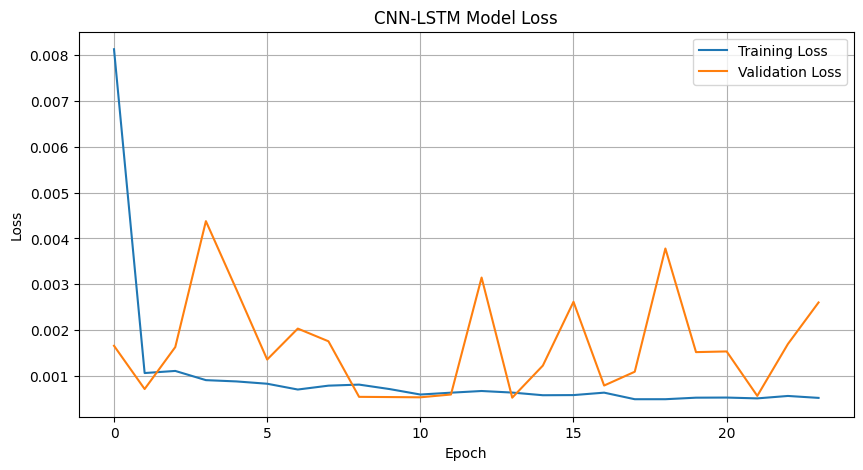

In [33]:
# ==========================================================
# STEP 4 : PLOT TRAINING HISTORY
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Training Loss
plt.plot(history.history['loss'], label='Training Loss')

# Validation Loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN-LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

Plot Training & Validation MAE
What is MAE?

MAE = Mean Absolute Error

It measures the average difference between the actual stock price and the predicted stock price.

Formula:

MAE=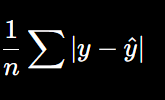


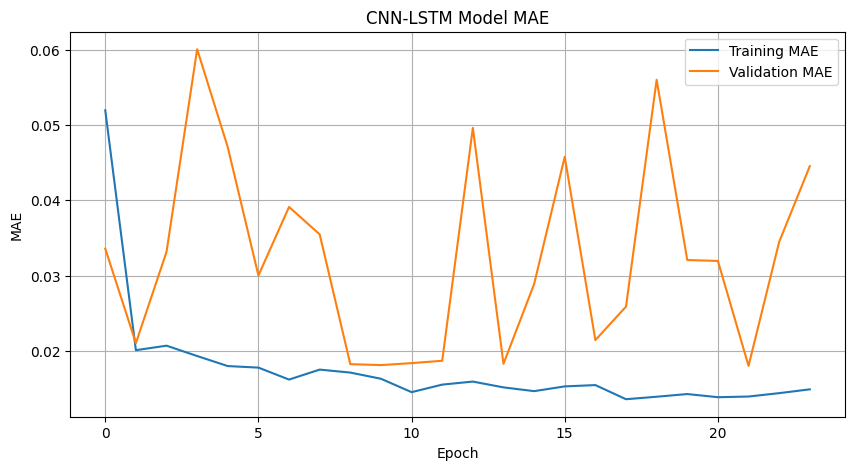

In [34]:
# ==========================================================
# STEP 5 : PLOT TRAINING MAE
# ==========================================================

plt.figure(figsize=(10,5))

# Training MAE
plt.plot(history.history['mae'], label='Training MAE')

# Validation MAE
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title("CNN-LSTM Model MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.show()

Phase 6: Model Evaluation

📌 Step 1: Predict Stock Prices
🎯 Objective

Use the trained CNN-LSTM model to predict stock prices for the test dataset.

In [35]:
# ==========================================================
# PHASE 6 : MODEL EVALUATION
# STEP 1 : PREDICT STOCK PRICES
# ==========================================================

# Use the trained model to predict stock prices
# X_test contains unseen data

predictions = model.predict(X_test)

# Display the first 10 predicted values
print("First 10 Predicted Values:")
print(predictions[:10])

# Display shape of predictions
print("\nPrediction Shape:")
print(predictions.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
First 10 Predicted Values:
[[0.48025963]
 [0.48305693]
 [0.48551124]
 [0.48864707]
 [0.49404034]
 [0.50004977]
 [0.5048748 ]
 [0.5099405 ]
 [0.5156322 ]
 [0.5198453 ]]

Prediction Shape:
(492, 1)


Step 2: Convert Predictions Back to Original Price Scale
🎯 Objective

The model predicts normalized values (0–1). Convert them back to the original stock prices using the saved MinMaxScaler.

In [36]:
# ==========================================================
# STEP 2 : CONVERT PREDICTIONS TO ORIGINAL SCALE
# ==========================================================

# Convert predicted values back to original stock prices
predictions = scaler.inverse_transform(predictions)

# Convert actual test values back to original stock prices
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Display first 10 values
comparison = pd.DataFrame({
    "Actual Price": actual_prices.flatten()[:10],
    "Predicted Price": predictions.flatten()[:10]
})

comparison

,Actual Price,Predicted Price
0,132.953476,134.296036
1,133.012482,134.958466
2,135.569107,135.539658
3,138.755035,136.282257
4,140.151291,137.559433
5,139.492508,138.982529
6,141.557434,140.125137
7,143.494598,141.324738
8,140.613525,142.672592
9,141.881943,143.670303


📌 Step 3: Calculate Evaluation Metrics
🎯 Objective

Measure how well the model predicts stock prices.

In [37]:
# ==========================================================
# STEP 3 : CALCULATE EVALUATION METRICS
# ==========================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

# Calculate RMSE
rmse = np.sqrt(
    mean_squared_error(actual_prices, predictions)
)

# Calculate MAE
mae = mean_absolute_error(
    actual_prices,
    predictions
)

# Calculate R² Score
r2 = r2_score(
    actual_prices,
    predictions
)

# Display evaluation metrics
print("=" * 40)
print("Model Evaluation Metrics")
print("=" * 40)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation Metrics
RMSE : 5.42
MAE  : 4.34
R²   : 0.9596


📌 Step 4: Plot Actual vs Predicted Stock Prices
🎯 Objective

Compare the model's predictions with the actual stock prices.

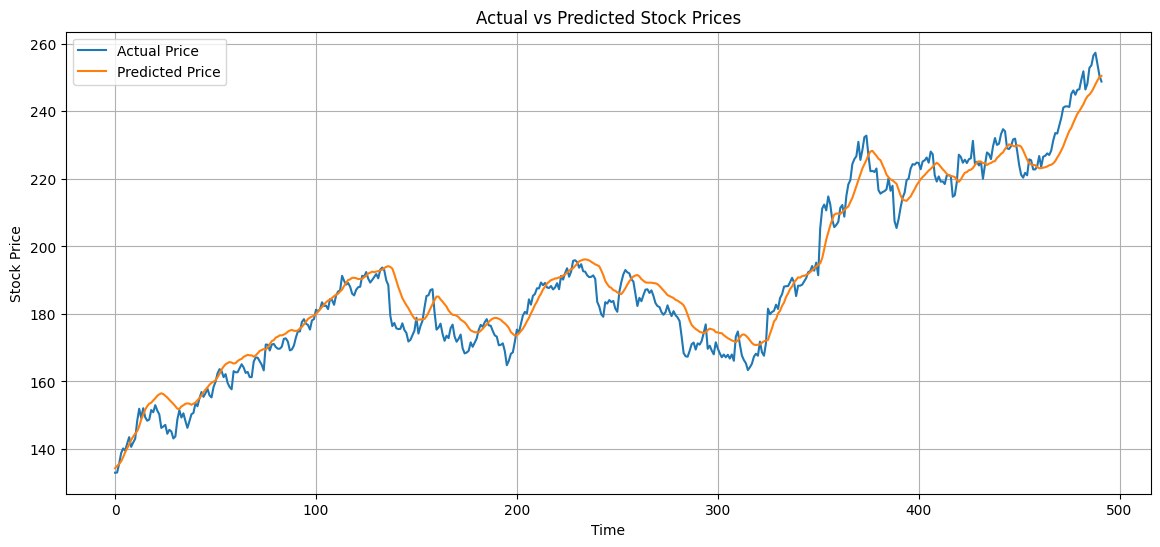

In [38]:
# ==========================================================
# STEP 4 : PLOT ACTUAL VS PREDICTED STOCK PRICES
# ==========================================================

plt.figure(figsize=(14,6))

# Plot actual stock prices
plt.plot(
    actual_prices,
    label="Actual Price"
)

# Plot predicted stock prices
plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.grid(True)

plt.show()

📌 Step 5: Save the Scaler
🎯 Objective

Save the MinMaxScaler so that new input data can be normalized in the same way during deployment.

In [56]:
# ==========================================================
# STEP 5 : SAVE MINMAX SCALER
# ==========================================================

import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the fitted MinMaxScaler
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("✅ Scaler saved successfully!")

✅ Scaler saved successfully!


In [57]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,923 (273.14 KB)

 Trainable params: 23,307 (91.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,616 (182.10 KB)